In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

In [3]:
def Loss_function(x):
    return (3*x**2-3*x+4)
def diff_loss_function(x):
    return (6*x-3)

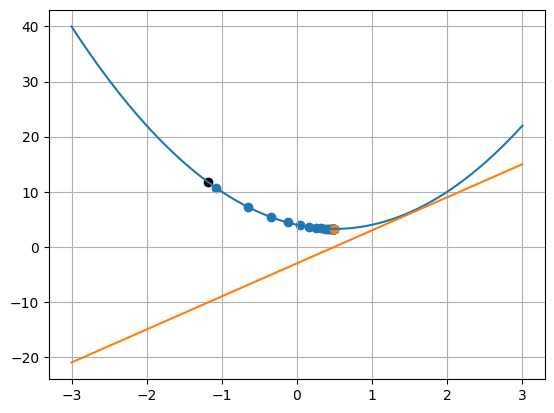

In [4]:
points=np.linspace(-3,3,2000)
y=Loss_function(points)
yd=diff_loss_function(points)

fig,ax=plt.subplots()

te=100
lr=0.01
xs=[]
ys=[]

x=np.random.choice(points,1)

ax.plot(points,y)
ax.plot(points,yd)
ax.scatter(x,Loss_function(x),c='Black')

for i in range(0,te):
    x=x-lr*diff_loss_function(x)
    if (i%5==0):
        xs.append(x)
        ys.append(Loss_function(x))

ax.scatter(xs,ys)
ax.scatter(x,Loss_function(x))

plt.grid(True)
plt.show()

In [5]:
#another Example :)
x=sp.Symbol('x')

def lfunc():
    return sp.log(x**2+1)+sp.sin(3*x)+0.1*x**2+sp.exp(-x**2)

def ldfunc():
    func=lfunc()
    return sp.diff(func,x)

def convert():
    loss_exp=lfunc()
    grad_exp=ldfunc()
    loss = sp.lambdify(x, loss_exp, "numpy")
    grad = sp.lambdify(x, grad_exp, "numpy")
    return loss,grad

lossfunc,gradfunc=convert()

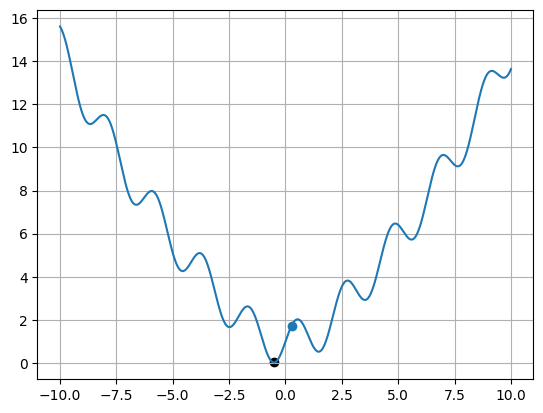

In [6]:
points=np.linspace(-10,10,2000)

x=np.random.choice(points)
fig,ax=plt.subplots()
ax.scatter(x,lossfunc(x))

y=lossfunc(points)

te=100
lr=0.01

for i in range(te):
    x=x-lr*gradfunc(x)

ax.plot(points,y)
ax.scatter(x,lossfunc(x),c='Black')

plt.grid(True)
plt.show()

In [23]:
# another 2D example 

x=sp.Symbol('x')
y=sp.Symbol('y')

def loss_function():
    return 3*(1-x)**2*sp.exp(-x**2-(y+1)**2)-10*((x/5)-x**3-y**5)*sp.exp((-x**2-y**2))-(1/3)*sp.exp(-(x+1)**2-y**2)

def dxloss_function():
    func=loss_function()
    return sp.diff(func,x)
def dyloss_function():
    func=loss_function()
    return sp.diff(func,y)

def convert():
    loss_exp=loss_function()
    dx_loss_exp=dxloss_function()
    dy_loss_exp=dyloss_function()
    loss=sp.lambdify((x,y),loss_exp,"numpy")
    dx=sp.lambdify((x,y),dx_loss_exp,"numpy")
    dy=sp.lambdify((x,y),dy_loss_exp,"numpy")
    return loss,dx,dy

loss,dx,dy=convert()

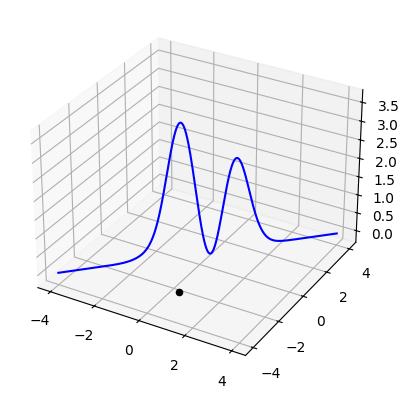

In [24]:
point_x=np.linspace(-4,4,1000)
point_y=np.linspace(-4,4,1000)

xx=np.random.choice(point_x)
yy=np.random.choice(point_y)

z=loss(point_x,point_y)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the 3D line
ax.plot3D(point_x, point_y, z, 'blue')
ax.scatter(xx,yy,c='Black')


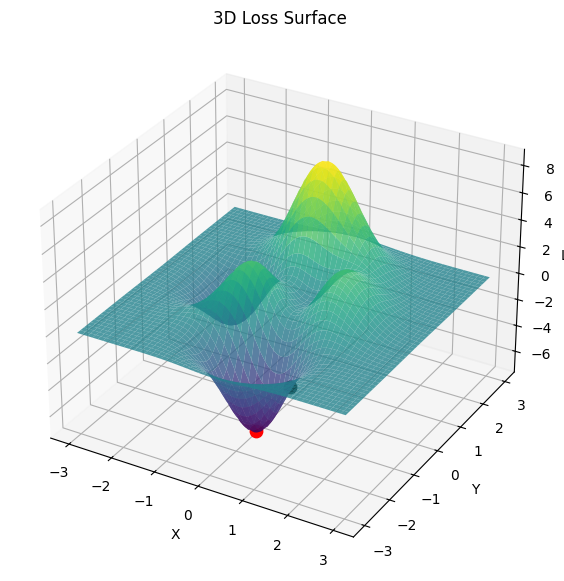

0.22827892055636925 -1.625534957499996 -6.551133332835836 8.881784197001252e-16 9.992007221626409e-15


In [27]:
# create grid
point_x = np.linspace(-3, 3, 400)
point_y = np.linspace(-3, 3, 400)

X, Y = np.meshgrid(point_x, point_y)

# compute surface
Z = loss(X, Y)

# random point
xx = np.random.choice(point_x)
yy = np.random.choice(point_y)

zz = loss(xx, yy)

# plotting
fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(111, projection='3d')

# surface
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)

# random point
ax.scatter(xx, yy, zz, c='black', s=80)

te=500
lr=0.01

for i in range(te):
    gx = dx(xx, yy)
    gy = dy(xx, yy)

    xx = xx - lr * gx
    yy = yy - lr * gy

# labels
ax.scatter(xx,yy,loss(xx,yy),c='red',s=80)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Loss")

ax.set_title("3D Loss Surface")

plt.show()
print(xx,yy,loss(xx,yy),gx,gy)

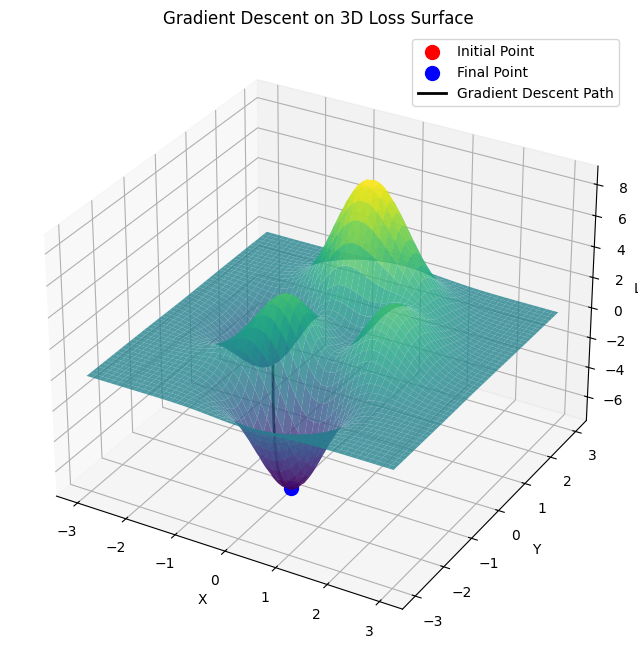


Initial Point:
-0.4285714285714288 -1.0751879699248121 1.2455271021221572

Final Point:
0.22827892055636897 -1.6255349574999969 -6.551133332835839

Gradient:
4.440892098500626e-16 -9.992007221626409e-15


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# ---------------------------------------------------
# SYMBOLIC VARIABLES
# ---------------------------------------------------

x = sp.Symbol('x')
y = sp.Symbol('y')

# ---------------------------------------------------
# LOSS FUNCTION
# ---------------------------------------------------

def loss_function():

    return (
        3*(1-x)**2 * sp.exp(-x**2 - (y+1)**2)
        -10*((x/5) - x**3 - y**5) * sp.exp(-x**2 - y**2)
        -(1/3) * sp.exp(-(x+1)**2 - y**2)
    )

# ---------------------------------------------------
# PARTIAL DERIVATIVES
# ---------------------------------------------------

def dxloss_function():

    return sp.diff(loss_function(), x)

def dyloss_function():

    return sp.diff(loss_function(), y)

# ---------------------------------------------------
# CONVERT SYMBOLIC -> NUMERICAL
# ---------------------------------------------------

def convert():

    loss_exp = loss_function()

    dx_exp = dxloss_function()
    dy_exp = dyloss_function()

    loss = sp.lambdify((x, y), loss_exp, "numpy")

    dx = sp.lambdify((x, y), dx_exp, "numpy")
    dy = sp.lambdify((x, y), dy_exp, "numpy")

    return loss, dx, dy

loss, xgrad, ygrad = convert()

# ---------------------------------------------------
# CREATE GRID
# ---------------------------------------------------

point_x = np.linspace(-3, 3, 400)
point_y = np.linspace(-3, 3, 400)

X, Y = np.meshgrid(point_x, point_y)

Z = loss(X, Y)

# ---------------------------------------------------
# RANDOM INITIAL POINT
# ---------------------------------------------------

xx = np.random.choice(point_x)
yy = np.random.choice(point_y)

# STORE INITIAL POINT
initial_x = xx
initial_y = yy
initial_z = loss(xx, yy)

# ---------------------------------------------------
# GRADIENT DESCENT
# ---------------------------------------------------

lr = 0.01
te = 500

x_path = [xx]
y_path = [yy]
z_path = [loss(xx, yy)]

for i in range(te):

    gx = xgrad(xx, yy)
    gy = ygrad(xx, yy)

    xx = xx - lr * gx
    yy = yy - lr * gy

    zz = loss(xx, yy)

    x_path.append(xx)
    y_path.append(yy)
    z_path.append(zz)

# FINAL POINT
final_x = xx
final_y = yy
final_z = zz

# ---------------------------------------------------
# PLOTTING
# ---------------------------------------------------

fig = plt.figure(figsize=(12,8))

ax = fig.add_subplot(111, projection='3d')

# SURFACE
ax.plot_surface(
    X,
    Y,
    Z,
    cmap='viridis',
    alpha=0.8
)

# ---------------------------------------------------
# INITIAL POINT (RED)
# ---------------------------------------------------

ax.scatter(
    initial_x,
    initial_y,
    initial_z,
    c='red',
    s=100,
    label='Initial Point'
)

# ---------------------------------------------------
# FINAL POINT (BLUE)
# ---------------------------------------------------

ax.scatter(
    final_x,
    final_y,
    final_z,
    c='blue',
    s=100,
    label='Final Point'
)

# ---------------------------------------------------
# PATH TRACE
# ---------------------------------------------------

ax.plot(
    x_path,
    y_path,
    z_path,
    c='black',
    linewidth=2,
    label='Gradient Descent Path'
)

# ---------------------------------------------------
# LABELS
# ---------------------------------------------------

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Loss")

ax.set_title("Gradient Descent on 3D Loss Surface")

ax.legend()

plt.show()

# ---------------------------------------------------
# FINAL VALUES
# ---------------------------------------------------

print("\nInitial Point:")
print(initial_x, initial_y, initial_z)

print("\nFinal Point:")
print(final_x, final_y, final_z)

print("\nGradient:")
print(gx,gy)

# So final take down of gradient descent is that is: 

## 1.Picks up random variable on plot
## 2.pick optimal learning rate(lr) and Traning epochs(te).
## 3.Moves in a direction where slope/gradient decreases 

### formula is x=x-lr*grad(x) for 1d
### formula is x=x-lr*dx(x,y), y=y-lr*dr(x,y) for 2-variable

### so for n-variable its x1=x1-lr * dx1(x1,x2,x3...,xn)+x2=x2-lr * dx2(x1,x2,x3...,xn)+....+xn=xn-lr * dxn(x1,x2,x3...,xn)